<h1 align="center">Neural Networks Regression Business Case</h1>
<p align="center"><b>By Atharva Nitin Deshpande (Scaler DSML August 2024 Batch)</b></p>

## Introduction

**Problem Statement**

Porter, India's largest marketplace for intra-city logistics, is revolutionizing the delivery sector with technology-driven solutions. This case focuses on leveraging neural networks to accurately predict delivery times, a critical aspect of customer satisfaction in logistics. With a dataset encompassing various aspects of orders and deliveries, Porter aims to refine its delivery time estimations. Analyzing this dataset can provide significant insights into delivery dynamics, efficiency bottlenecks, and optimization opportunities. The insights obtained can enhance Porter's operational efficiency, ensuring timely deliveries and improving driver-partner allocation.

Let us now begin this business case by importing important libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras.utils import plot_model
import pydot
from sklearn.metrics import r2_score
import joblib

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Let us now import the raw data.

In [2]:
raw_data = pd.read_csv('data_2.csv')
df = raw_data.copy(deep=True)

In [3]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [4]:
df.tail()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
175772,1.0,2015-02-17 00:19:41,2015-02-17 01:02:41,28,4.0,3,1389,3,345,649,17.0,17.0,23.0,331.0
175773,1.0,2015-02-13 00:01:59,2015-02-13 01:03:59,28,4.0,6,3010,4,405,825,12.0,11.0,14.0,915.0
175774,1.0,2015-01-24 04:46:08,2015-01-24 05:32:08,28,4.0,5,1836,3,300,399,39.0,41.0,40.0,795.0
175775,1.0,2015-02-01 18:18:15,2015-02-01 19:03:15,58,1.0,1,1175,1,535,535,7.0,7.0,12.0,384.0
175776,1.0,2015-02-08 19:24:33,2015-02-08 20:01:33,58,1.0,4,2605,4,425,750,20.0,20.0,23.0,134.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

Each row in this data corresponds to one unique delivery. Each column corresponds to a feature as explained below.

`market_id` : integer id for the market where the restaurant lies

`created_at` : the timestamp at which the order was placed

`actual_delivery_time` : the timestamp when the order was delivered

`store_primary_category` : category for the restaurant

`order_protocol` : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, pre booked, third part etc)

`total_items subtotal` : final price of the order

`num_distinct_items` : the number of distinct items in the order

`min_item_price` : price of the cheapest item in the order

`max_item_price` : price of the costliest item in order

`total_onshift_partners` : number of delivery partners on duty at the time order was placed

`total_busy_partners` : number of delivery partners attending to other tasks

`total_outstanding_orders` : total number of orders to be fulfilled at the moment

`estimated_store_to_consumer_driving_duration` : approximate travel time from restaurant to customer

In [6]:
# Number of unique values
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')

market_id: 6
created_at: 162649
actual_delivery_time: 160344
store_primary_category: 73
order_protocol: 7
total_items: 54
subtotal: 8182
num_distinct_items: 20
min_item_price: 2251
max_item_price: 2585
total_onshift_dashers: 172
total_busy_dashers: 158
total_outstanding_orders: 281
estimated_store_to_consumer_driving_duration: 1318


In [7]:
# Inspect market_id, store_primary_category and order_protocol
for col in ['market_id', 'store_primary_category', 'order_protocol']:
    print(f'{col}\n{df[col].unique()}\n')

market_id
[1. 2. 3. 4. 5. 6.]

store_primary_category
[ 4 46 36 38 58 68 15 57 55 20 60 13 45 39 34 18 29 23 50 70  6  7 10 28
 24 61 59 72 16 65 47 53 49 40 66 42 21 14 35 11 52  2 71 25 54 69 26 12
 32 30 17 33 22 31  0 51 48 67 44 62  9 27 19  1  5 41 37 64 56 63 43  8
  3]

order_protocol
[1. 2. 3. 5. 4. 6. 7.]



In [8]:
# Convert market_id, store_primary_category and order_protocol to category
for col in ['market_id', 'store_primary_category', 'order_protocol']:
    df[col] = df[col].astype(int).astype('category')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_items,175777.0,3.204976,2.674055,1.0,2.0,3.0,4.0,411.0
subtotal,175777.0,2697.111147,1828.554893,0.0,1412.0,2224.0,3410.0,26800.0
num_distinct_items,175777.0,2.675060,1.625681,1.0,1.0,2.0,3.0,20.0
min_item_price,175777.0,684.965433,519.882924,-86.0,299.0,595.0,942.0,14700.0
max_item_price,175777.0,1160.158616,560.828571,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_dashers,175777.0,44.918664,34.544724,-4.0,17.0,37.0,66.0,171.0
total_busy_dashers,175777.0,41.861381,32.168505,-5.0,15.0,35.0,63.0,154.0
total_outstanding_orders,175777.0,58.230115,52.731043,-6.0,17.0,41.0,85.0,285.0
estimated_store_to_consumer_driving_duration,175777.0,546.077240,218.717798,0.0,384.0,544.0,703.0,2088.0


In [10]:
df.describe(include=['object','category']).T

,count,unique,top,freq
market_id,175777,6,2,53469
created_at,175777,162649,2015-02-11 19:50:43,6
actual_delivery_time,175777,160344,2015-02-14 02:58:40,5
store_primary_category,175777,73,4,18183
order_protocol,175777,7,1,48404


In [11]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

Columns `created_at` and `actual_delivery_time` are of the datetime format. The target variable for this study, `estimated_delivery_time`, is to be derived from the difference between them.

In [12]:
# FEATURE ENGINEERING

# Let us convert created_at and actual_delivery_time into valid datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

# Getting hour of day from the order time and also the day of the week
df['hour_of_day'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_of_week

# The target variable for this study, 'estimated_delivery_time', is to be derived from the difference between 'created_at' and 'actual_delivery_time'.
df['estimated_delivery_time'] = (df['actual_delivery_time'] - df['created_at']).dt.seconds/60

In [13]:
# We can drop the datetime columns now
df.drop(columns=['created_at','actual_delivery_time'], inplace=True)

## EDA - Univariate Analysis

### Numerical Features

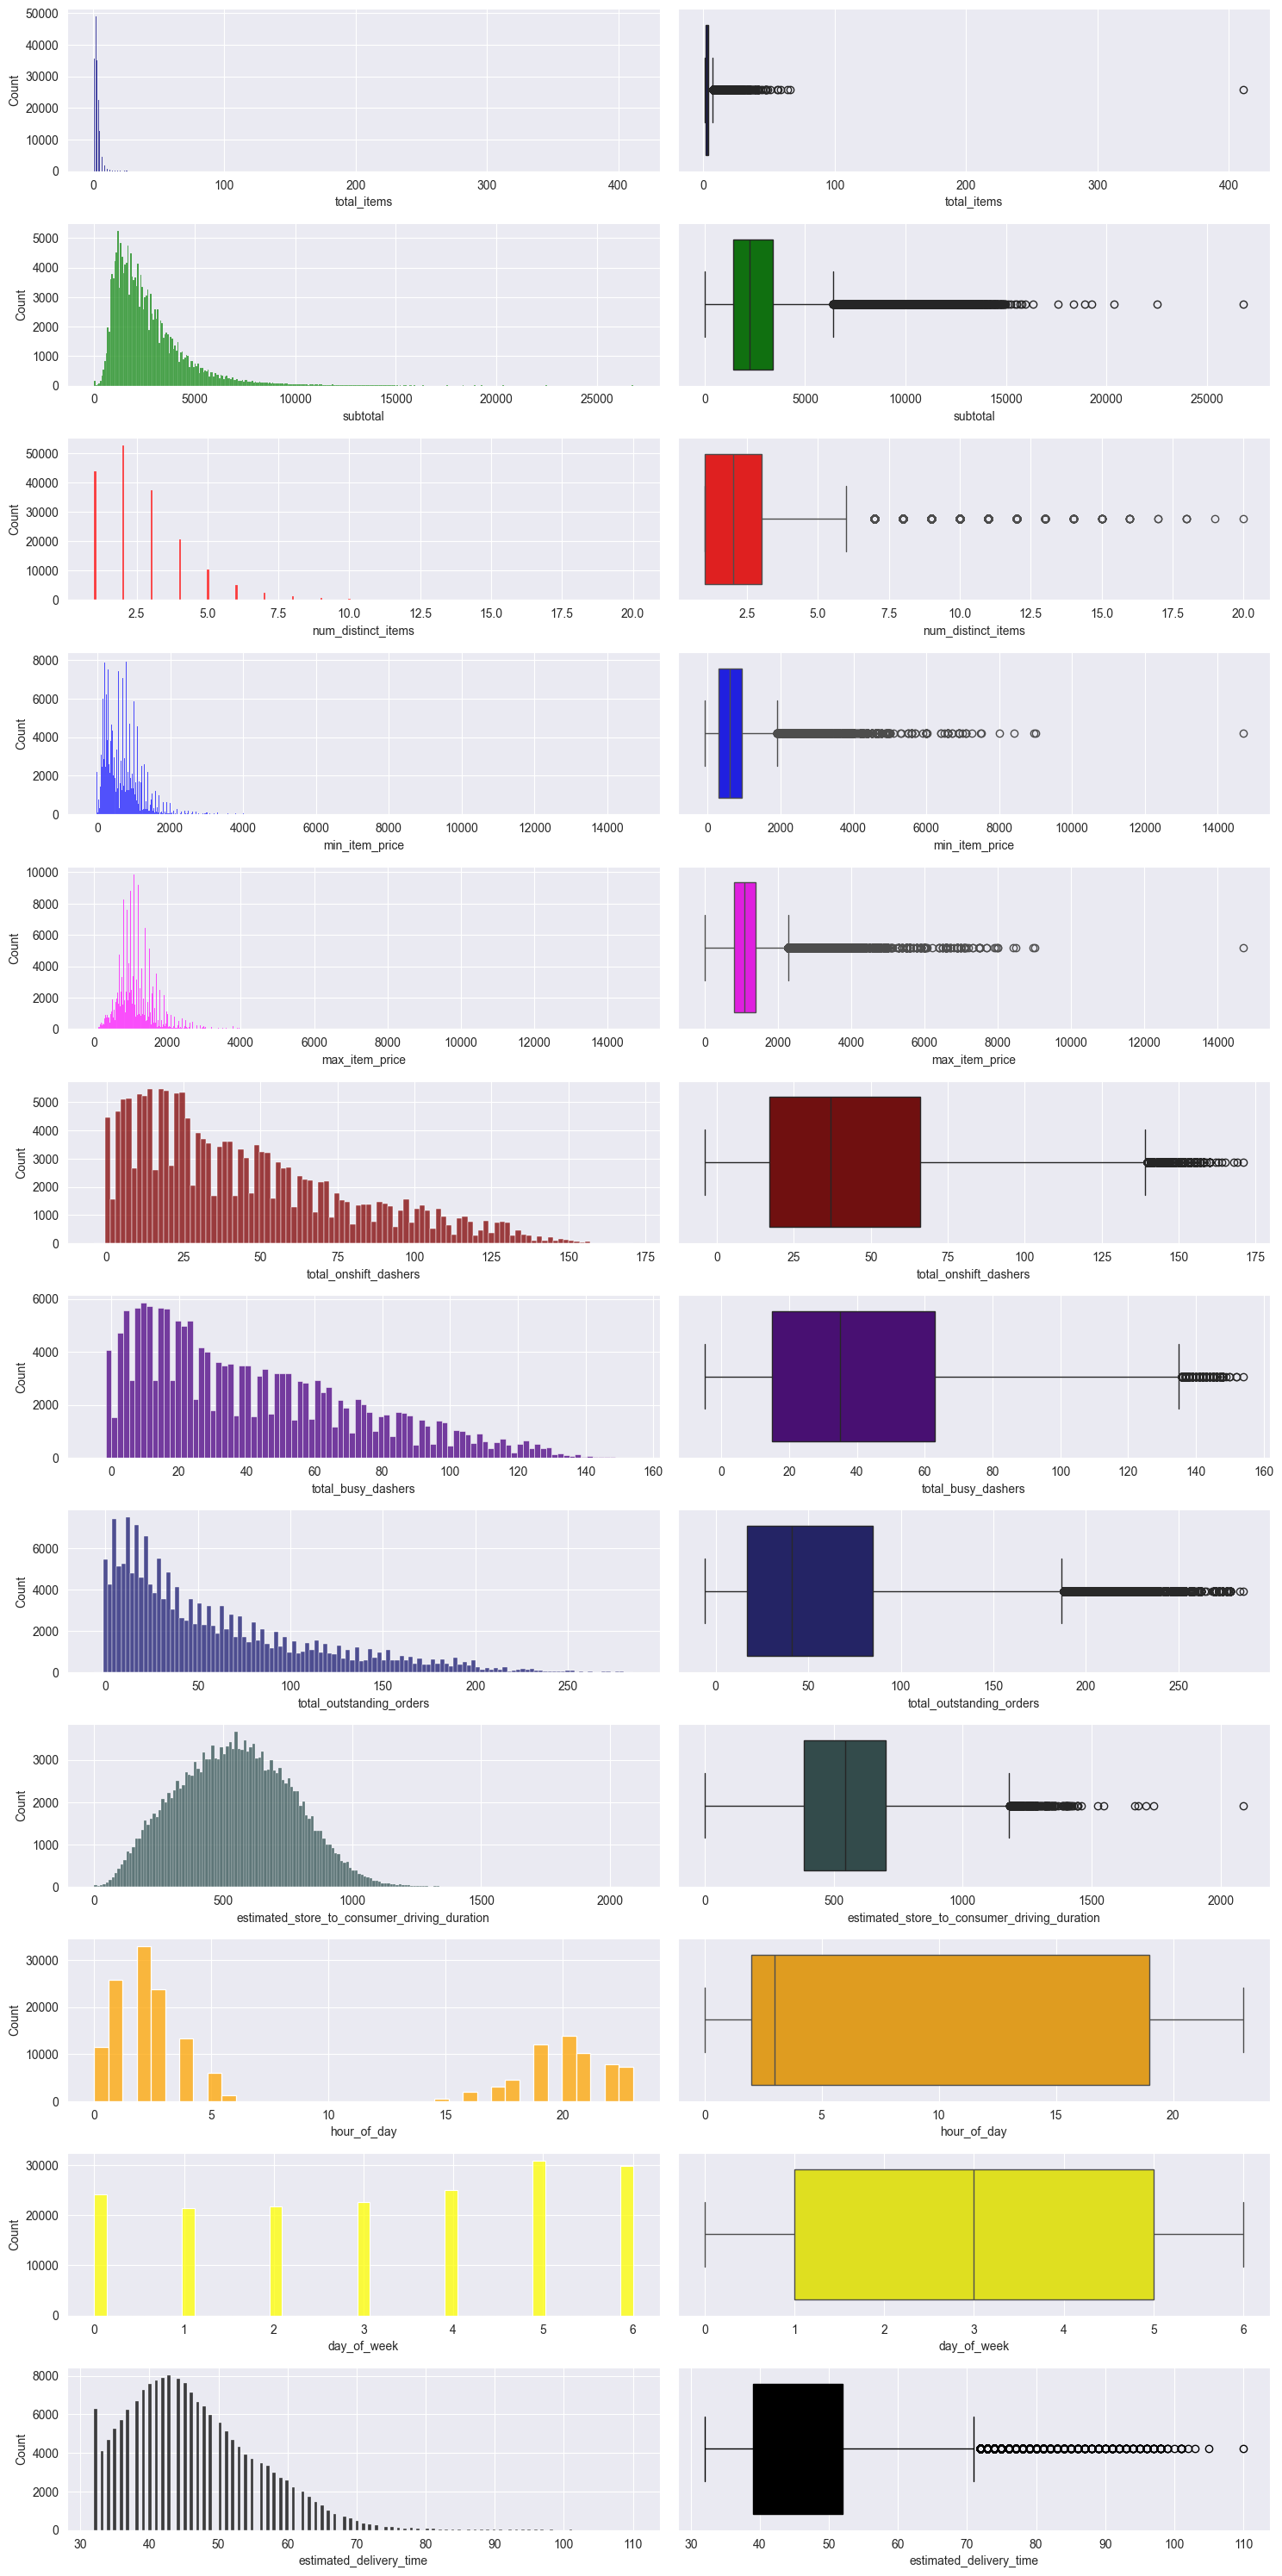

In [14]:
num_cols = df.select_dtypes(include='number')
grid_size = num_cols.shape[1]
colors = ['navy', 'green', 'red', 'blue', 'magenta', 'maroon', 'indigo', 'midnightblue', 'darkslategray', 'orange', 'yellow', 'black']
plt.figure(figsize=(15,30))
for i, col in enumerate(num_cols):
    plt.subplot(grid_size, 2, 2*i+1)
    sns.histplot(df[col], color=colors[i])
    plt.subplot(grid_size, 2, 2*i+2)
    sns.boxplot(x=df[col], color=colors[i])

plt.tight_layout()
plt.show()

In [15]:
# Capping Upper Outliers at 99.99th percentile values
for col in num_cols:
    df[col] = df[col].clip(upper=df[col].quantile(0.9999))

### Categorical Features

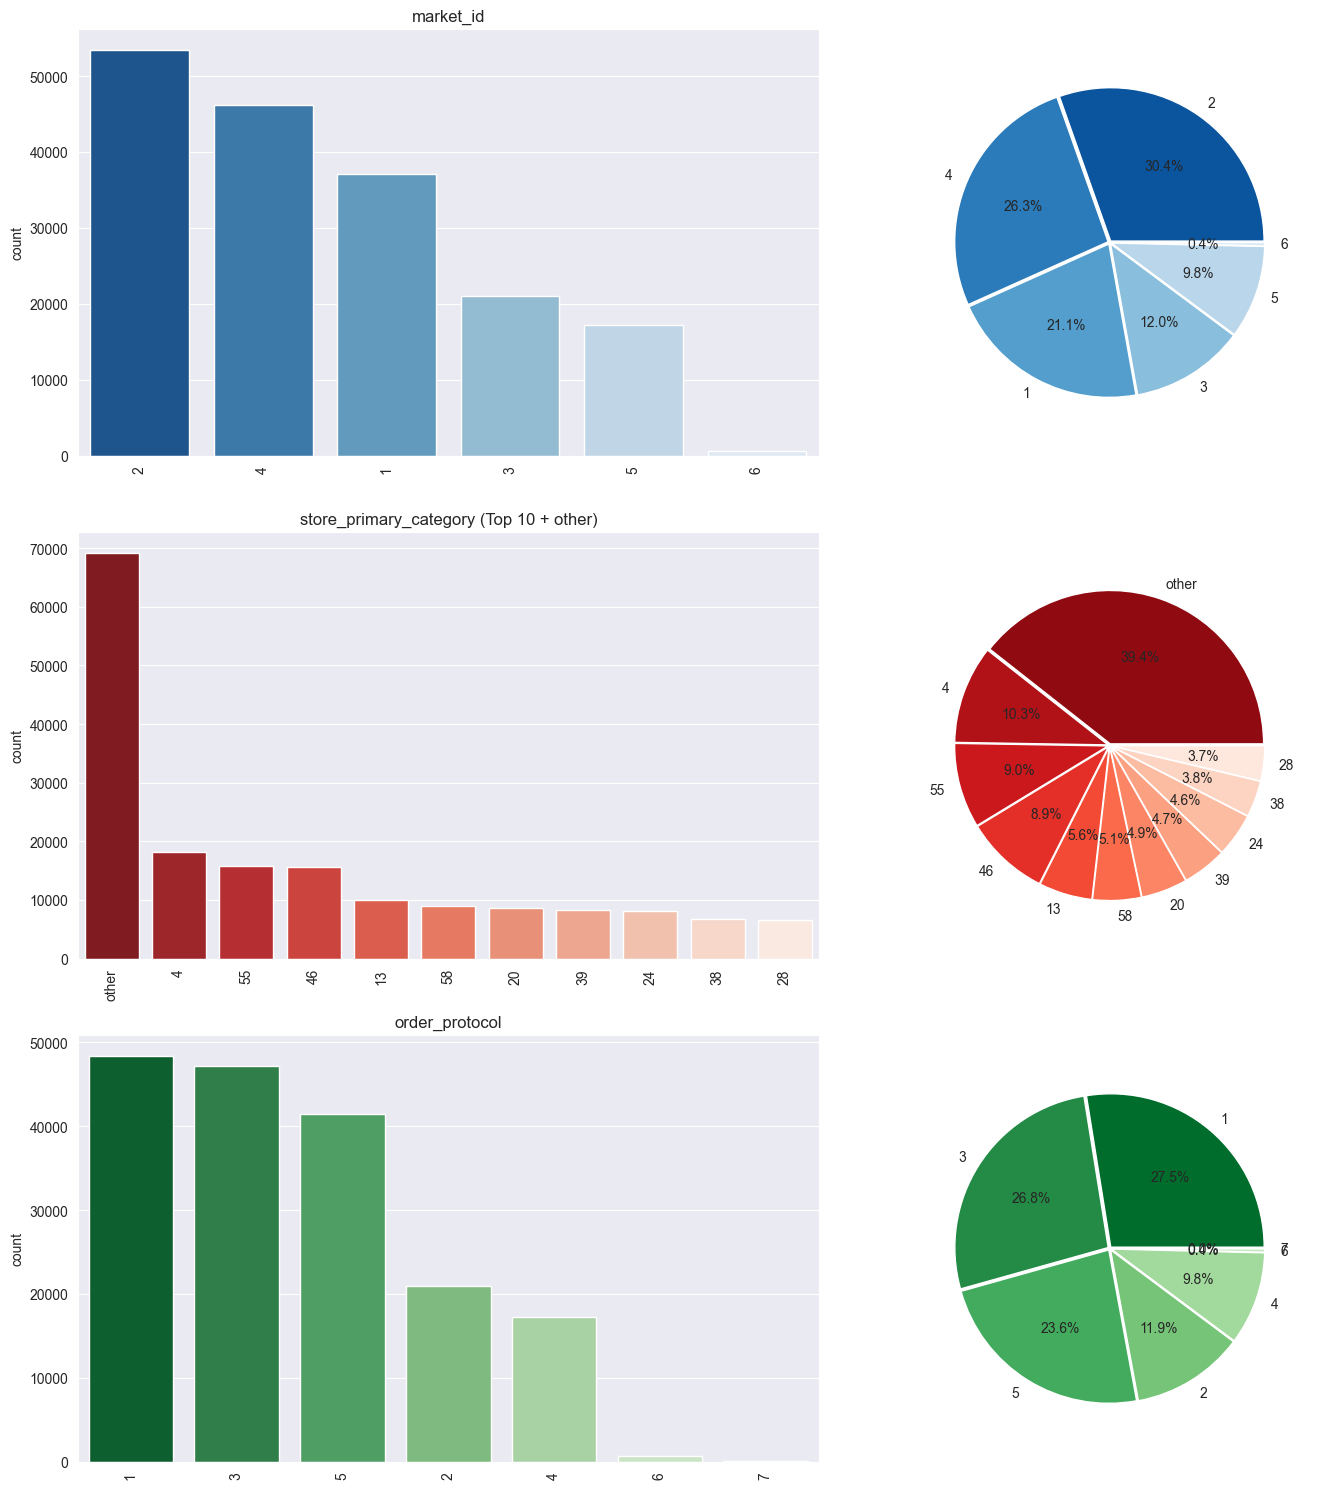

In [16]:
cat_cols = df.select_dtypes(exclude='number')
grid_size = cat_cols.shape[1]
palettes = ['Blues_r','Reds_r','Greens_r']
plt.figure(figsize=(15,15))
for i, col in enumerate(cat_cols):
    s = df[col]
    if s.nunique() > 10:
        s = s.apply(lambda x: 'other' if x not in s.value_counts()[:10].index else x)
        col = col + ' (Top 10 + other)'

    plt.subplot(grid_size, 2, 2*i+1)
    plt.title(col)
    sns.countplot(x=s, 
                  order=s.value_counts().index, 
                  hue=s, 
                  hue_order=s.value_counts().index,
                  legend=False, 
                  palette=palettes[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

        
    plt.subplot(grid_size, 2, 2*i+2)
    plt.pie(s.value_counts(), 
            labels=s.value_counts().index, 
            autopct="%1.1f%%", 
            explode=[0.01]*s.nunique(), 
            colors=sns.color_palette(palettes[i], 
                                     n_colors=len(s.value_counts().index)),
            radius=0.9)

plt.tight_layout()
plt.show()

## EDA - Multivariate Analysis

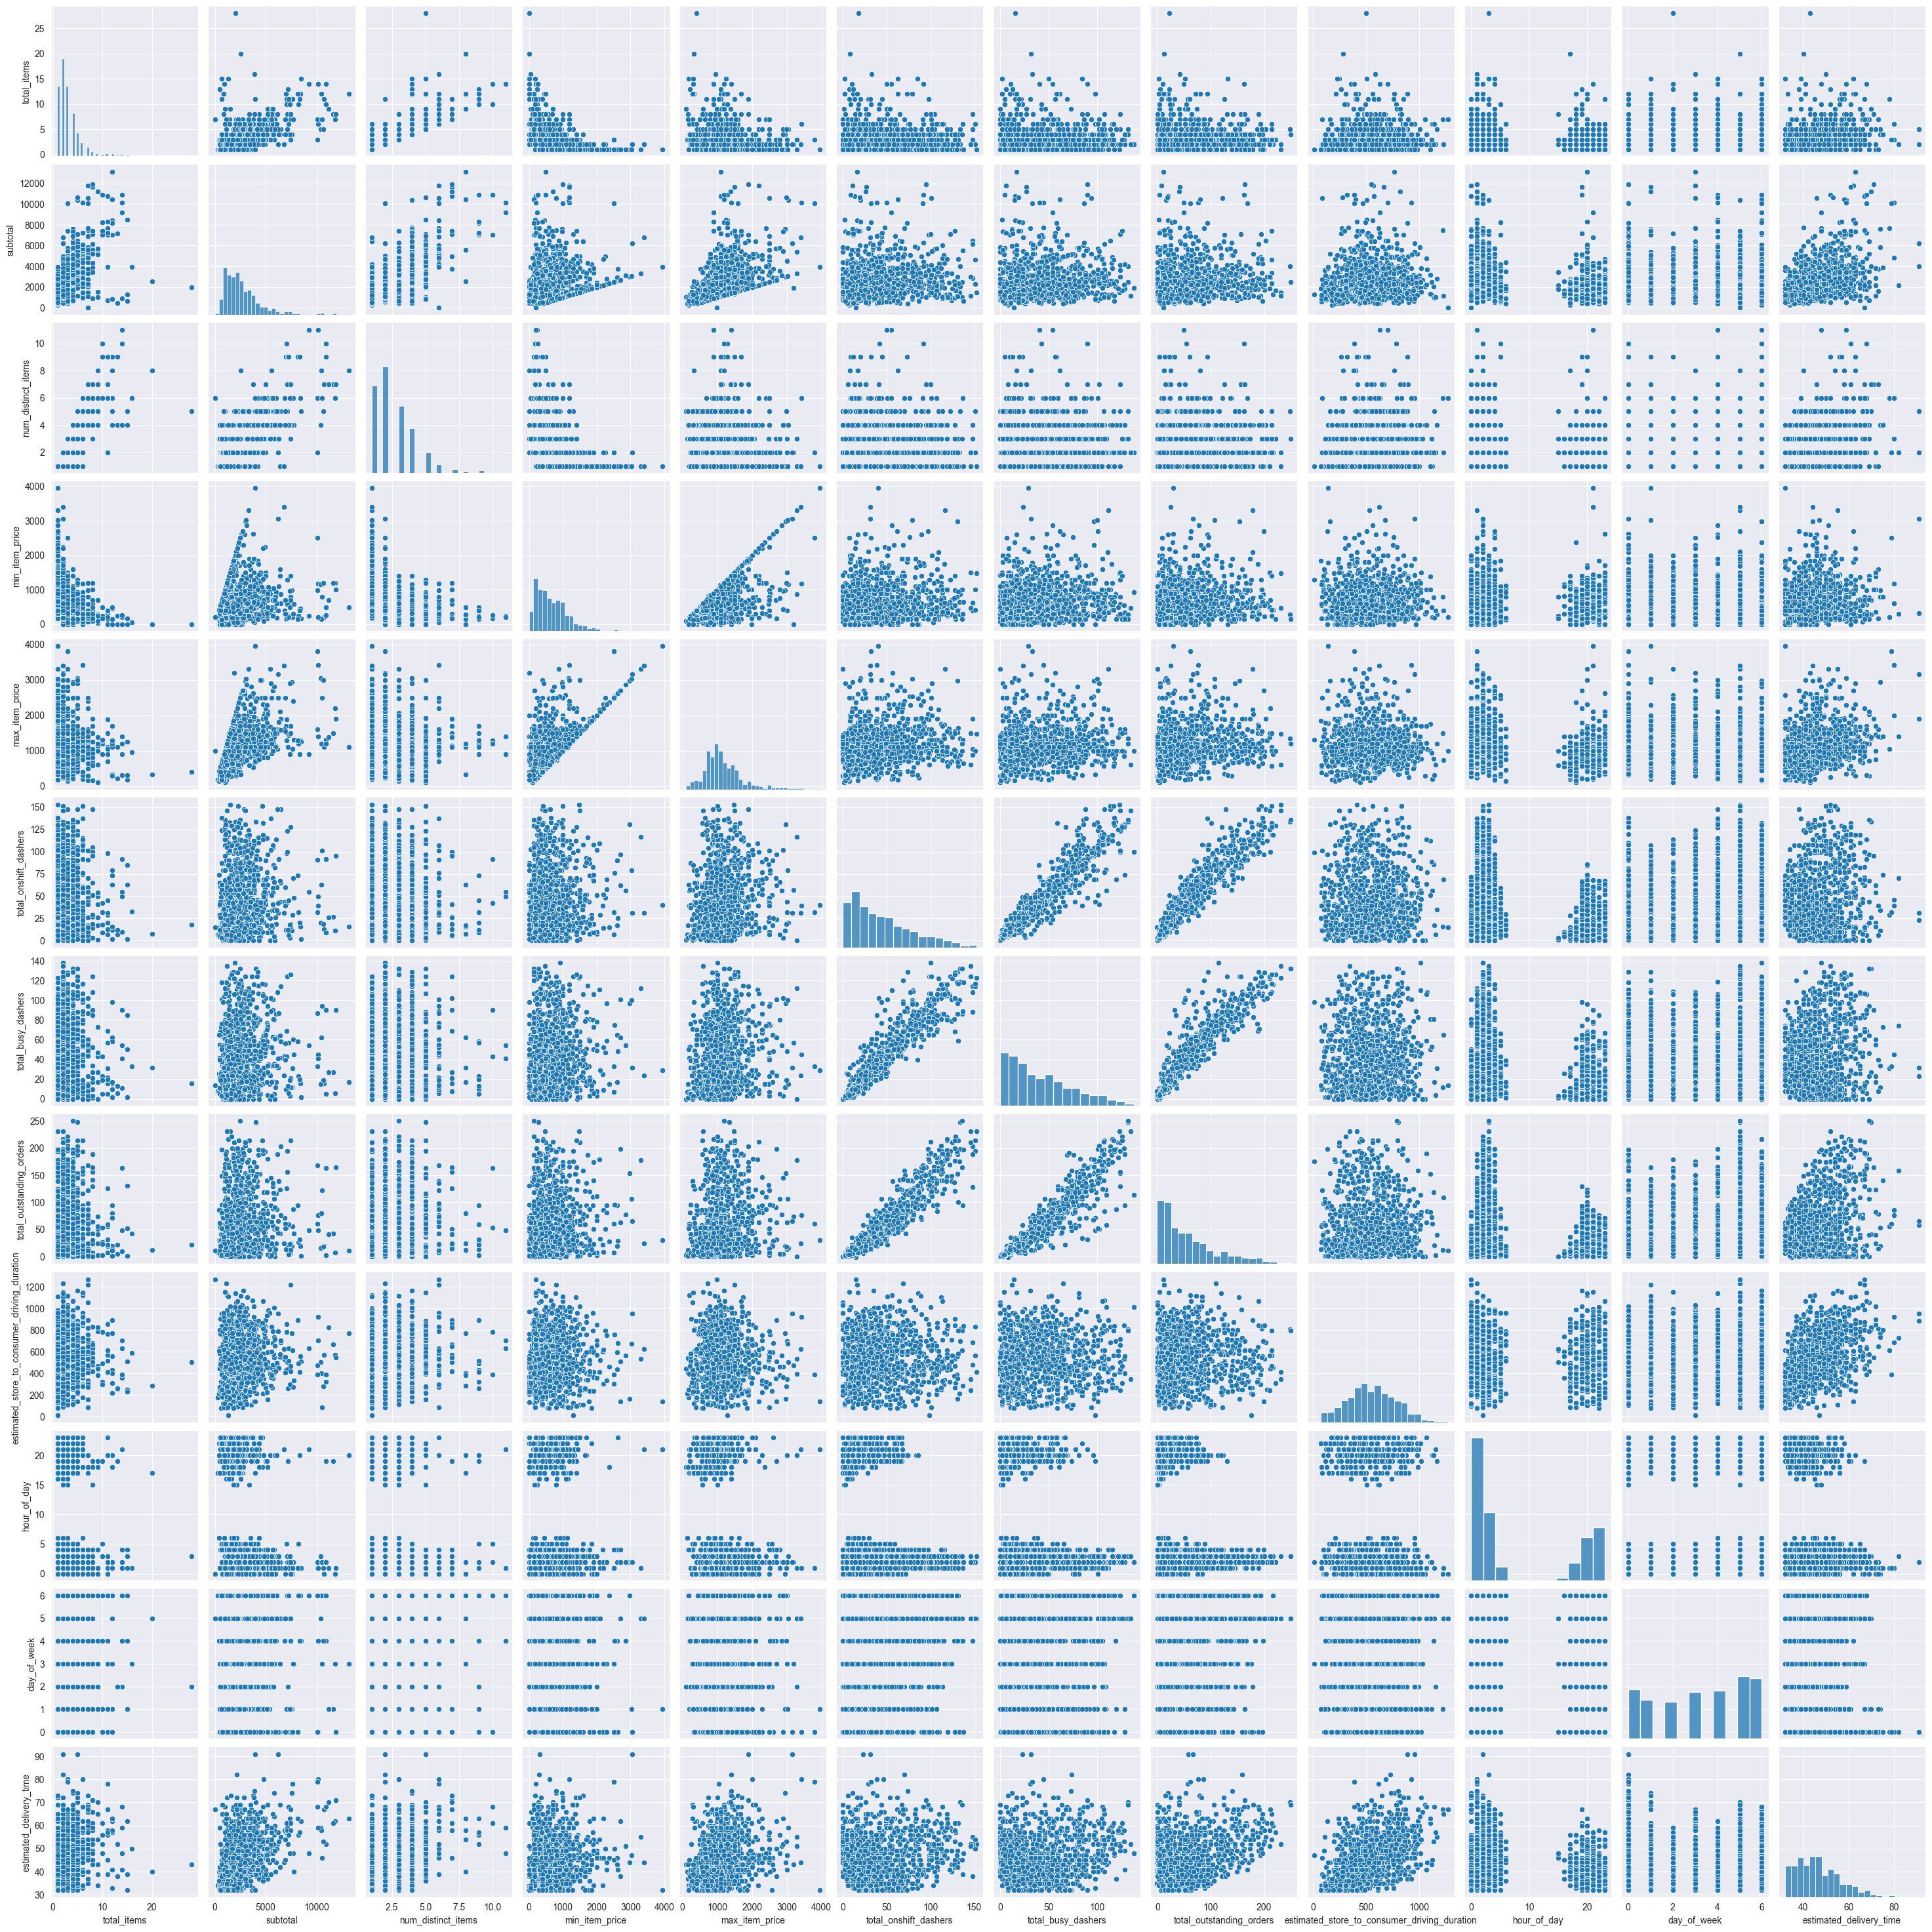

In [17]:
df_sample = df.sample(1000)
sns.pairplot(df_sample)
plt.show()

We can see that most of the features don't exhibit a clear linear pattern with each other.

Let us check for correlation.

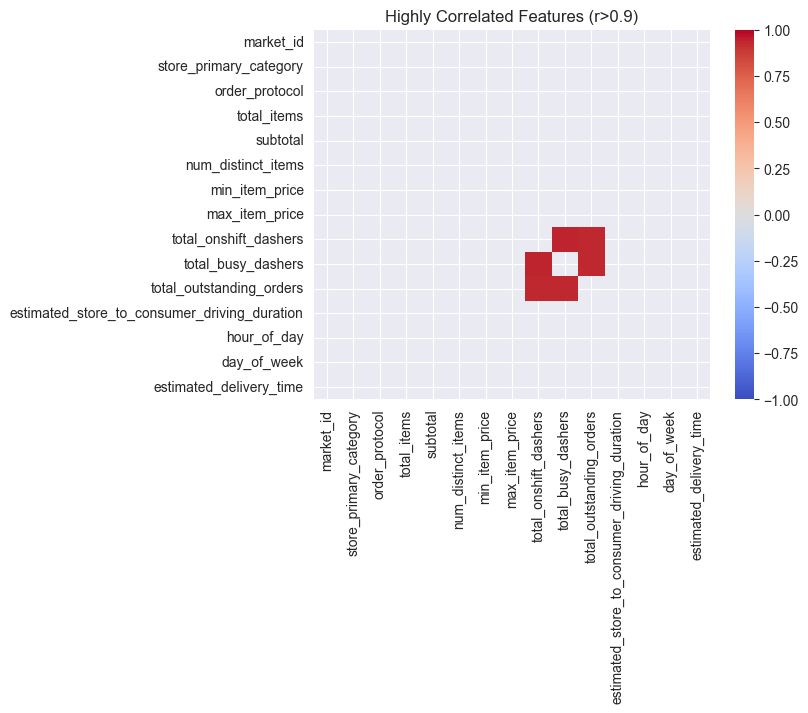

In [18]:
sns.heatmap(df.corr(), 
            vmin=-1, 
            vmax=1, 
            cmap='coolwarm',
            mask=((abs(df.corr())<0.9)|(df.corr()==1))
            )
plt.title('Highly Correlated Features (r>0.9)')
plt.show()

The features `total_onshift_dashers`, `total_busy_dashers` and `total_outstanding_orders` are highly correlated with each other, with correlation coefficient > 0.9. 

In [19]:
# hour_of_day and day_of_week encoding
# cyclical variables - use sine cosine encoding

df["hour_of_day_sin"] = np.sin(2*np.pi*df["hour_of_day"]/24)
df["hour_of_day_cos"] = np.cos(2*np.pi*df["hour_of_day"]/24)

df['day_of_week_sin'] = np.sin(2*np.pi*df["day_of_week"]/7)
df['day_of_week_cos'] = np.cos(2*np.pi*df["day_of_week"]/7)

# We can now remove the original columns
df.drop(columns = ['hour_of_day','day_of_week'], inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 17 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   market_id                                     175777 non-null  category
 1   store_primary_category                        175777 non-null  category
 2   order_protocol                                175777 non-null  category
 3   total_items                                   175777 non-null  int64   
 4   subtotal                                      175777 non-null  float64 
 5   num_distinct_items                            175777 non-null  int64   
 6   min_item_price                                175777 non-null  float64 
 7   max_item_price                                175777 non-null  float64 
 8   total_onshift_dashers                         175777 non-null  float64 
 9   total_busy_dashers                   

## Data Preparation for Modelling

In [21]:
# Split X and y
X = df.drop(columns=['estimated_delivery_time'])
y = df['estimated_delivery_time']

In [22]:
# train, validation and test split

# first split: train vs temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [23]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(exclude='number').columns
print(f'NUMERICAL COLUMNS\n{num_cols}\n')
print(F'CATEGORICAL COLUMNS:\n{cat_cols}')

NUMERICAL COLUMNS
Index(['total_items', 'subtotal', 'num_distinct_items', 'min_item_price',
       'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration', 'hour_of_day_sin',
       'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos'],
      dtype='object')

CATEGORICAL COLUMNS:
Index(['market_id', 'store_primary_category', 'order_protocol'], dtype='object')


**Why scaling is required for Neural Networks?**

Scaling is required because neural networks are sensitive to the magnitude of input features. If features have very different ranges, gradients can become unstable: some weights update too much, others too little. Scaling (like standardization or normalization) ensures:

- Faster convergence during training.
- Balanced weight updates across all features.
- Helps activation functions (like sigmoid, tanh, ReLU) operate in their effective range.
- Reduces risk of vanishing/exploding gradients.
- Without scaling, the network can take longer to train or fail to learn properly.

In [24]:
# Numerical feature scaling
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

In [25]:
# Convert categorical columns to integer indices
cat_maps = {}
cat_sizes = {}

for col in cat_cols:
    
    categories = df[col].unique()
    mapping = {k:v for v,k in enumerate(categories)}
    
    cat_maps[col] = mapping
    cat_sizes[col] = int(df[col].nunique())
    
    X_train[col] = X_train[col].map(mapping).cat.codes.astype('int32')
    X_val[col] = X_val[col].map(mapping).cat.codes.astype('int32')

print(f'===CATEGORICAL MAPPINGS===')
for k in cat_maps:
    print(f'{k}: {cat_maps[k]}')
print(f'\n===SIZES===')
for k in cat_sizes:
    print(f'{k}: {cat_sizes[k]}')

===CATEGORICAL MAPPINGS===
market_id: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
store_primary_category: {4: 0, 46: 1, 36: 2, 38: 3, 58: 4, 68: 5, 15: 6, 57: 7, 55: 8, 20: 9, 60: 10, 13: 11, 45: 12, 39: 13, 34: 14, 18: 15, 29: 16, 23: 17, 50: 18, 70: 19, 6: 20, 7: 21, 10: 22, 28: 23, 24: 24, 61: 25, 59: 26, 72: 27, 16: 28, 65: 29, 47: 30, 53: 31, 49: 32, 40: 33, 66: 34, 42: 35, 21: 36, 14: 37, 35: 38, 11: 39, 52: 40, 2: 41, 71: 42, 25: 43, 54: 44, 69: 45, 26: 46, 12: 47, 32: 48, 30: 49, 17: 50, 33: 51, 22: 52, 31: 53, 0: 54, 51: 55, 48: 56, 67: 57, 44: 58, 62: 59, 9: 60, 27: 61, 19: 62, 1: 63, 5: 64, 41: 65, 37: 66, 64: 67, 56: 68, 63: 69, 43: 70, 8: 71, 3: 72}
order_protocol: {1: 0, 2: 1, 3: 2, 5: 3, 4: 4, 6: 5, 7: 6}

===SIZES===
market_id: 6
store_primary_category: 73
order_protocol: 7


In [26]:
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(cat_maps, "artifacts/categorical_mappings.pkl")
joblib.dump(cat_sizes, "artifacts/categorical_sizes.pkl")

['artifacts/categorical_sizes.pkl']

## Model Building

The following function defines the neural network architecture used for the regression task. The model is implemented using the **TensorFlow/Keras Functional API** to support multiple input types.

**Input Structure**

The network accepts two types of inputs:

1. Numerical Features
   - All numerical variables are standardized using `StandardScaler`.
   - These features are passed directly into the network as a dense input layer.

2. Categorical Features
   - Each categorical variable is processed using a learned embedding layer.
   - Embeddings allow the model to learn dense vector representations for categorical levels instead of relying on one-hot encoding.
   - The embedding dimension follows a common heuristic:  
     `min(50, category_size // 2 + 1)`.

All numerical inputs and categorical embeddings are concatenated into a single feature vector before being passed into the dense network.

**Hidden Layers**

The dense portion of the network is dynamically defined and tuned using Keras Tuner. The following hyperparameters are explored:

- *Number of hidden layers:* 1 to 3
- *Units per layer:* 64 to 256 (step size 64)
- *Batch Normalization:* optionally applied after each dense layer
- *Dropout:* optional dropout regularization
- *Dropout rate:* 0.1 to 0.3

Each dense layer uses:

- *He Normal initialization* for better convergence with ReLU activations
- *ReLU activation*
- *Bias disabled when Batch Normalization is used*

**Output Layer**

The final layer is a single neuron with *linear activation*, suitable for a regression problem.

**Optimization**

The model is trained using:

- *Optimizer:* Adam
- *Loss function:* Mean Squared Error (MSE)
- *Evaluation metric:* Mean Absolute Error (MAE)

The learning rate of the optimizer is also treated as a hyperparameter and sampled on a **log scale** during tuning.

This flexible architecture allows the model to automatically search for the best network configuration for the dataset while efficiently handling both numerical and categorical features.

In [85]:
def build_model(hp):
    inputs = []
    embeddings = []

    # numerical input
    num_input = keras.layers.Input(shape=(len(num_cols),), name="num_input")
    inputs.append(num_input)
    embeddings.append(num_input)

    # Categorical Embeddings
    for col in cat_cols:
        inp = keras.Input(shape=(1,), name=f'{col}_input')
        emb_dim = min(50, cat_sizes[col]//2+1) # common heuristic
        emb = keras.layers.Embedding(input_dim=cat_sizes[col], output_dim=emb_dim)(inp)
        emb = keras.layers.Flatten()(emb)
        inputs.append(inp)
        embeddings.append(emb)

    x = keras.layers.Concatenate()(embeddings)

    # Dense layers
    for i in range(hp.Int("num_layers", 2, 3)):
        x = keras.layers.Dense(
            units=hp.Int(f"units_{i+1}", 64, 256, step=64),
            use_bias=False,
            kernel_initializer='he_normal'
        )(x)
        if hp.Boolean(f"batchnorm_{i+1}"):
            x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation("relu")(x)
        if hp.Boolean(f"dropout_{i+1}"):
            x = keras.layers.Dropout(hp.Choice('dropout', [0.15,0.3]))(x)

    # Output
    output = keras.layers.Dense(1, activation="linear")(x)

    # Full model
    model = keras.Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

**Adam Optimizer**
- Adam combines momentum and adaptive learning rates.
- Works well for sparse gradients and non-stationary objectives.
- Handles learning rate tuning automatically, reducing manual effort.
- Commonly chosen for regression because it converges faster and is robust to noisy gradients.

**ReLU Activation Function**
- ReLU (Rectified Linear Unit): `f(x) = max(0, x)`
- Advantages:
  - Avoids vanishing gradients (common in sigmoid/tanh).
  - Computationally efficient (simple thresholding).
  - Introduces non-linearity, enabling NN to learn complex relationships.
- For regression, it helps model positive and sparse activations efficiently.

**He-Normal Kernel Initialization**
- He initialization: weights sampled from `N(0, sqrt(2/fan_in))`.
- Works well with ReLU activations.
- Prevents vanishing/exploding gradients at the start of training.
- Ensures signal flows properly through deep layers.

**Why Scaling is Required for Neural Networks**
- Neural networks are sensitive to feature magnitude differences.
- Scaling (e.g., StandardScaler or MinMaxScaler):
  - Speeds up convergence.
  - Prevents some features dominating gradients.
  - Helps regularization methods like weight decay work properly.
- Essential when inputs vary widely (e.g., age in years vs. salary in lakhs).

**Why Neural Network Performs Well on Large Datasets**
- Neural networks have high capacity, i.e., can approximate complex functions.
- Large datasets:
  - Provide diverse examples for learning patterns.
  - Reduce overfitting risk by exposing the model to more variation.
  - Allow deep architectures to generalize better.
- Small datasets often lead to overfitting because NN memorizes instead of generalizing.

Let us now define inputs for model.

In [ ]:
train_inputs = {
    "num_input": X_train[num_cols].values
}

val_inputs = {
    "num_input": X_val[num_cols].values
}

for col in cat_cols:
    train_inputs[f"{col}_input"] = X_train[col].values
    val_inputs[f"{col}_input"] = X_val[col].values

***Training Callbacks***

Two callbacks are used during training to improve convergence and prevent unnecessary training.

**Early Stopping**

`EarlyStopping` monitors the validation loss during training. If the validation loss does not improve for a specified number of epochs (`patience`), training stops early. The option `restore_best_weights=True` ensures that the model weights from the best validation performance are retained. This helps prevent overfitting and reduces wasted computation.

**Reduce Learning Rate on Plateau**

`ReduceLROnPlateau` monitors the validation loss and reduces the learning rate when improvement stalls. If the validation loss does not improve for a certain number of epochs, the learning rate is multiplied by a factor (e.g., 0.3). Lowering the learning rate allows the optimizer to make finer updates and often helps the model converge to a better minimum.

In [87]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True, 
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=5,
        min_lr=1e-6, 
        verbose=1
    )
]

We use keras' `Hyperband` as Hyperparameter Tuning tool.

In [88]:
tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=100,
    factor=3,
    directory="tuner_dir",
    project_name="tabular_ann"
)

Let us now search for Hyperparameters.

In [89]:
tuner.search(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=100,
    batch_size=256,
    callbacks = callbacks
)

Trial 145 Complete [00h 00m 49s]
val_loss: 0.15138332545757294

Best val_loss So Far: 0.14648333191871643
Total elapsed time: 00h 20m 29s

Search: Running Trial #146

Value             |Best Value So Far |Hyperparameter
3                 |2                 |num_layers
256               |256               |units_1
True              |False             |batchnorm_1
True              |False             |dropout_1
256               |256               |units_2
True              |False             |batchnorm_2
False             |False             |dropout_2
0.15              |0.3               |dropout
256               |128               |units_3
True              |True              |batchnorm_3
False             |True              |dropout_3
34                |34                |tuner/epochs
12                |12                |tuner/initial_epoch
4                 |4                 |tuner/bracket
3                 |3                 |tuner/round
0137              |0140              |tune

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.3721 - mae: 0.9039 - val_loss: 0.4768 - val_mae: 0.5444 - learning_rate: 0.0010
Epoch 14/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.2246 - mae: 0.8530 - val_loss: 0.5287 - val_mae: 0.5860 - learning_rate: 0.0010
Epoch 15/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1912 - mae: 0.8471 - val_loss: 0.3514 - val_mae: 0.4677 - learning_rate: 0.0010
Epoch 16/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1607 - mae: 0.8350 - val_loss: 0.5076 - val_mae: 0.5749 - learning_rate: 0.0010
Epoch 17/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1416 - mae: 0.8286 - val_loss: 0.5821 - val_mae: 0.6070 - learning_rate: 0.0010
Epoch 18/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.0851 - mae: 0.8103 - val_loss: 0.5356 - val_mae: 0.5770 - learning_rate: 0.0010
Epoch 19/34
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.0135 - mae: 0.7797 - val_loss: 0.2309 - val_mae: 0.3796 - learning_rate: 0.0010
Epoch 20/34

KeyboardInterrupt: 

In [90]:
best_hp = tuner.get_best_hyperparameters(1)[0]

These are the best hyperparameters.

In [91]:
best_hp.values

{'num_layers': 2,
 'units_1': 256,
 'batchnorm_1': False,
 'dropout_1': False,
 'units_2': 256,
 'batchnorm_2': False,
 'dropout_2': False,
 'dropout': 0.3,
 'units_3': 128,
 'batchnorm_3': True,
 'dropout_3': True,
 'tuner/epochs': 34,
 'tuner/initial_epoch': 12,
 'tuner/bracket': 4,
 'tuner/round': 3,
 'tuner/trial_id': '0140'}

In [92]:
best_model = tuner.hypermodel.build(best_hp)

In [93]:
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ market_id_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_primary_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ order_protocol_inp… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 4)      │         24 │ market_id_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 37)     │      2,701 │ store_primary_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 4)      │         28 │ order_protocol_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 37)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4)         │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 58)        │          0 │ num_input[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     14,848 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ dense_4[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     65,536 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 256)       │          0 │ dense_5[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │        257 │ activation_4[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,394 (325.76 KB)

 Trainable params: 83,394 (325.76 KB)

 Non-trainable params: 0 (0.00 B)

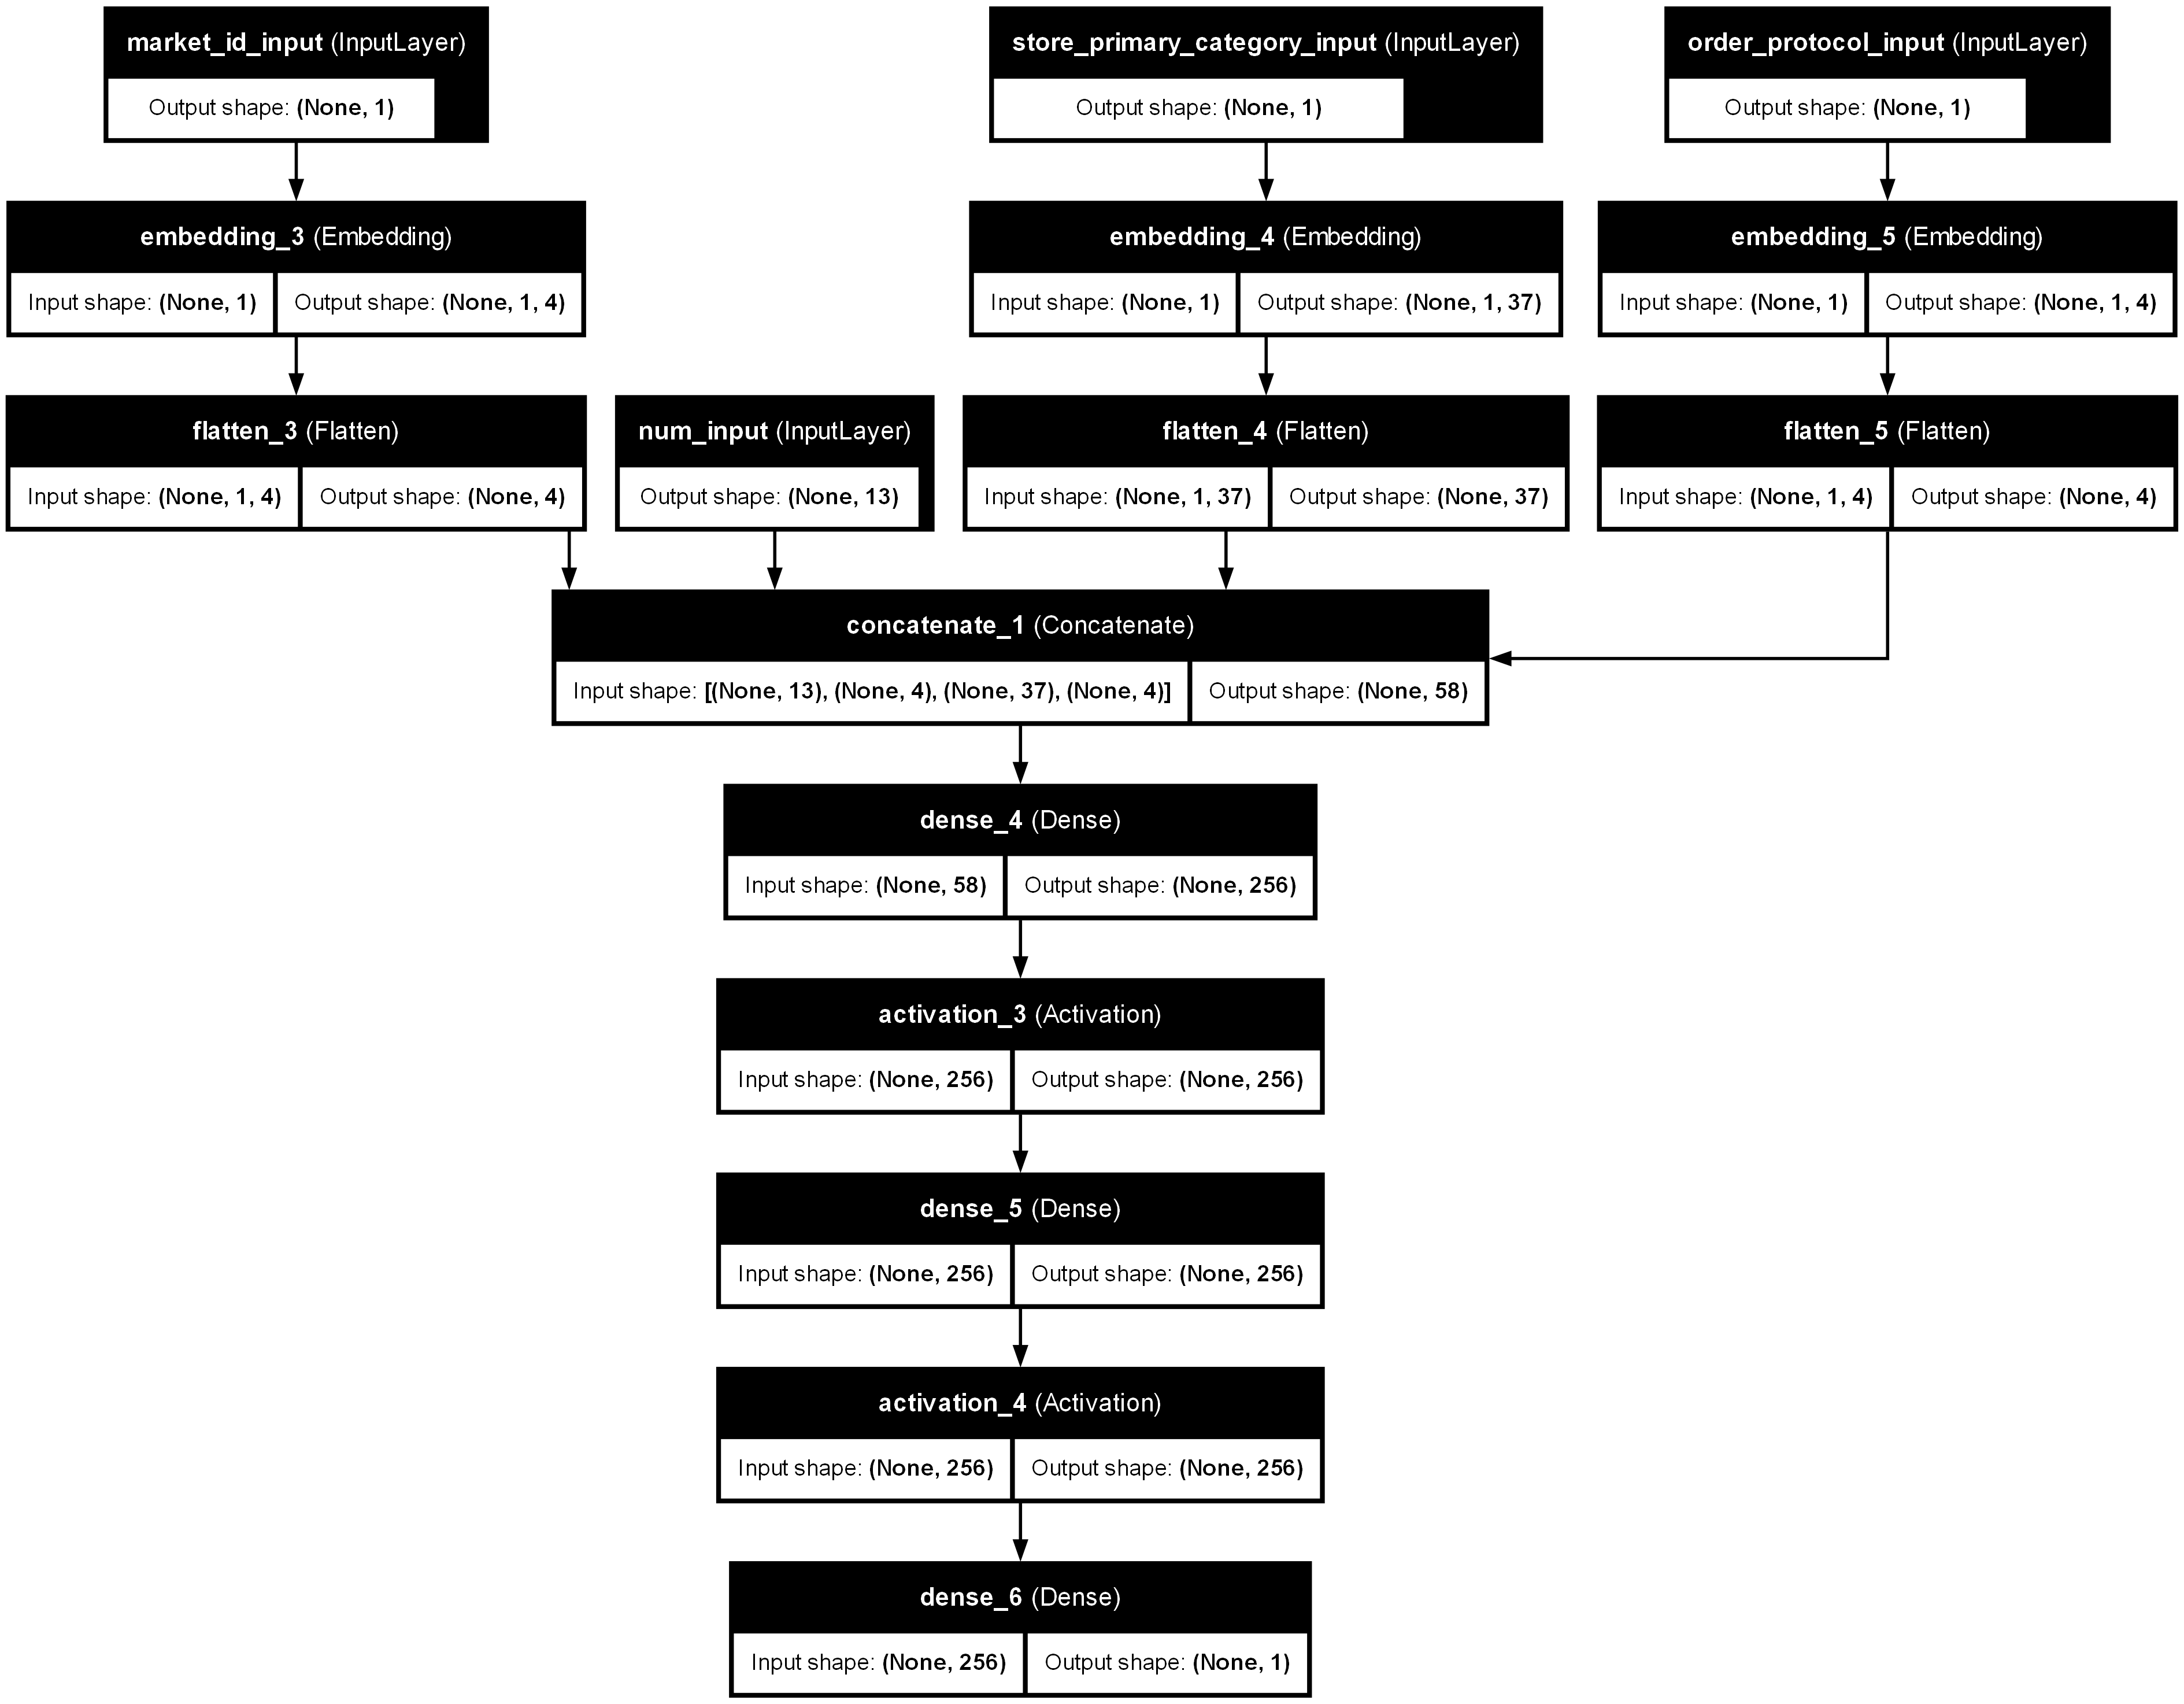

In [94]:
plot_model(best_model, to_file='trained_model.png', show_shapes=True, show_layer_names=True)

Let us now train the full model with best performing hyperparameters:

In [95]:
history = best_model.fit(train_inputs, 
               y_train,
               validation_data=(val_inputs, y_val),
               epochs=100,
               callbacks=callbacks,
               verbose=1)

Epoch 1/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 19.4596 - mae: 2.0610 - val_loss: 2.2293 - val_mae: 1.1468 - learning_rate: 0.0010
Epoch 2/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.1516 - mae: 0.8088 - val_loss: 0.5891 - val_mae: 0.5820 - learning_rate: 0.0010
Epoch 3/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.5383 - mae: 0.5617 - val_loss: 0.5954 - val_mae: 0.6217 - learning_rate: 0.0010
Epoch 4/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.3781 - mae: 0.4776 - val_loss: 0.3301 - val_mae: 0.4529 - learning_rate: 0.0010
Epoch 5/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.3232 - mae: 0.4423 - val_loss: 0.3023 - val_mae: 0.4367 - learning_rate: 0.0010
Epoch 6/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.2749 - mae: 0.4111 - val_loss: 0.2781 - val_mae: 0.4169 - learning_rate: 0.0010
Epoch 7/100
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.2597 - mae: 0.3980 - val_loss: 0.2639 - val_mae: 0.4098 - learni

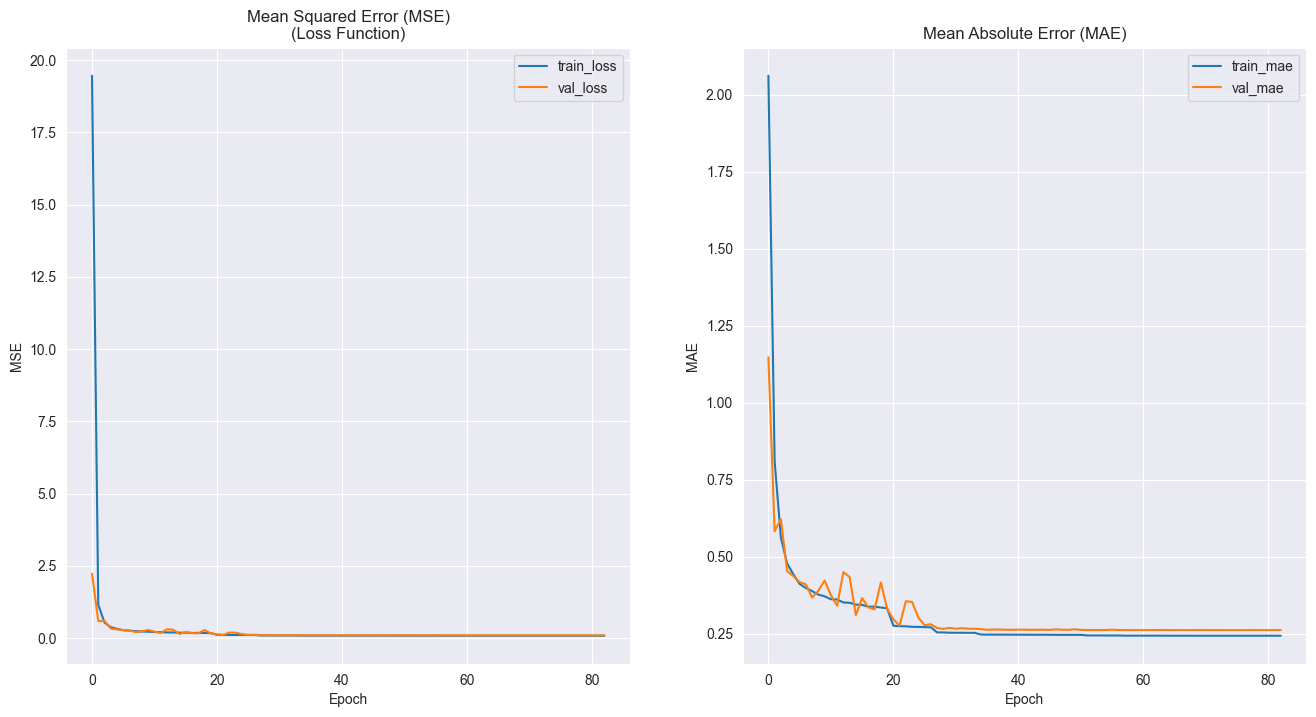

In [96]:
plt.figure(figsize=(16,8))

plt.subplot(1,2,1)
plt.title('Mean Squared Error (MSE)\n(Loss Function)')
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.subplot(1,2,2)
plt.title('Mean Absolute Error (MAE)')
plt.plot(history.history['mae'], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.show()

**Training and Validation Performance**

The training and validation curves for **Mean Squared Error (MSE)** and **Mean Absolute Error (MAE)** show a stable learning process.

Both metrics decrease rapidly during the initial epochs, indicating that the model quickly learns the major patterns in the data. After approximately 25–30 epochs, the curves begin to plateau, suggesting that the model has largely converged and additional training provides minimal improvement.

The training and validation curves remain very close throughout the training process, with no significant divergence. This indicates that the model generalizes well to unseen data and does not exhibit signs of overfitting. Minor fluctuations in the validation curve during early epochs are expected and are typically caused by stochastic minibatch training and dropout regularization.

Overall, the smooth convergence and small gap between training and validation metrics suggest that the chosen architecture, regularization strategy, and optimization settings are appropriate for the problem.

In [120]:
def evaluate_test(model, X_test, y_test, num_cols, cat_cols, scaler):

    X_test1 = X_test.copy(deep=True)

    X_test1[num_cols] = scaler.transform(X_test1[num_cols])

    for col in cat_cols:
        categories = df[col].unique()
        mapping = {k:v for v,k in enumerate(categories)}
        cat_maps[col] = mapping
        cat_sizes[col] = int(df[col].nunique())
        X_test1[col] = X_test1[col].map(mapping).cat.codes.astype('int32')

    test_inputs = {
        "num_input": X_test1[num_cols].values
    }

    for col in cat_cols:
        test_inputs[f"{col}_input"] = X_test1[col].values

    # Keras evaluation
    loss, mae = model.evaluate(test_inputs, y_test, verbose=0)

    # Predictions
    preds = model.predict(test_inputs, verbose=0).flatten()

    # Extra metrics
    mse = np.mean((y_test - preds) ** 2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    print("===== TEST METRICS =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")

    plt.figure(figsize=(10,10))
    plt.title("NN Predictions vs Actual")
    plt.scatter(y_test, 
                preds, 
                s=5)
    plt.plot(np.arange(y_test.min()-1,y_test.max()+1,1), 
             np.arange(y_test.min()-1,y_test.max()+1,1), 
             color='black', 
             label='Diagonal Line')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.show()

===== TEST METRICS =====
MSE  : 0.0978
RMSE : 0.3127
MAE  : 0.2623
R2   : 0.9989


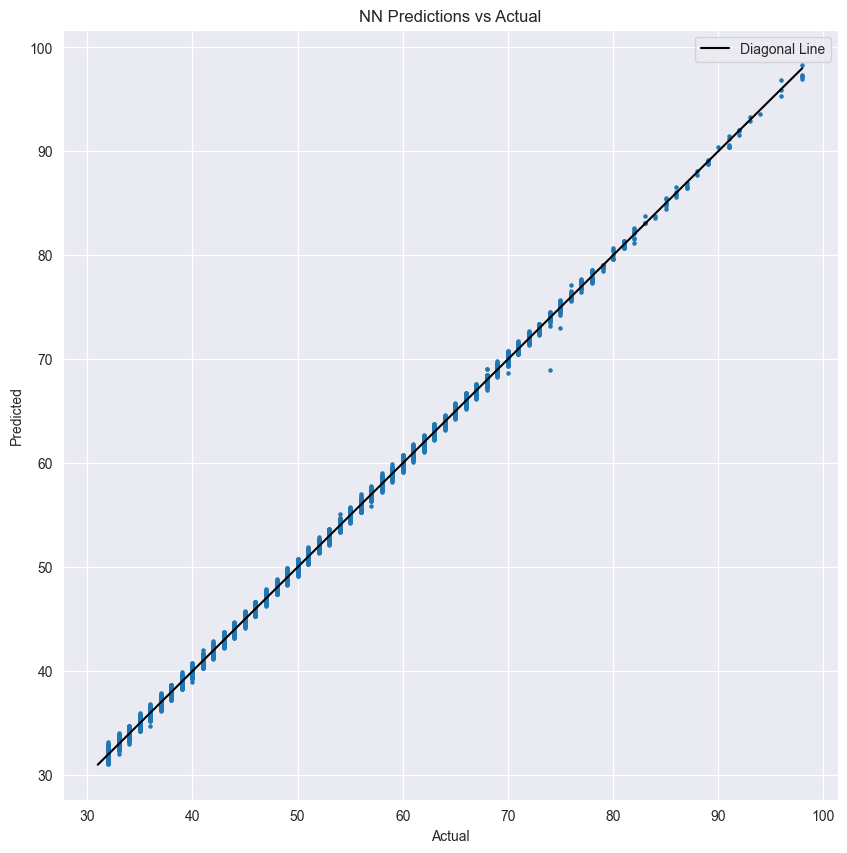

In [121]:
evaluate_test(best_model, X_test, y_test, num_cols, cat_cols, scaler)

Let us save our model with scaler.

In [124]:
joblib.dump(scaler, "scaler.pkl")
best_model.save("porter_best_model.keras")